# 2D Laplacian Problem

\begin{equation}
-\nabla^2u=f\space \space \space in \space \Omega
\end{equation}

\begin{equation}
u=0\space \space \space in\space\Gamma_D 
\end{equation}

In [0]:
%%capture
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *

In [0]:
from fenics import *
import matplotlib.pyplot as plt
import numpy as np

## Meshing

---



Vi sono 4 tipologie di mesh in 2D:

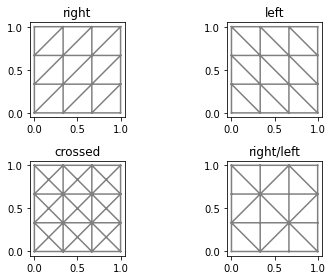

In [3]:
n=3
mesh1 = UnitSquareMesh(n, n, 'right')
mesh2 = UnitSquareMesh(n, n, 'left')
mesh3 = UnitSquareMesh(n, n, 'crossed')
mesh4 = UnitSquareMesh(n, n, 'right/left')

plt.subplot(2, 2, 1)
plot(mesh1, title="right")
plt.subplot(2, 2, 2)
plot(mesh2, title="left")
plt.subplot(2, 2, 3)
plot(mesh3, title="crossed")
plt.subplot(2, 2, 4)
plot(mesh4, title="right/left")
plt.tight_layout()
plt.show()

Nonostante la mesh crossed sia più raffinata, la dimensione della mesh è data dal lato più lungo di ogni triangolo. In particolare:
\begin{equation}
h\approx\frac{1}{LatoLungo}
\end{equation}

## Funzione risolutiva

---



In primo luogo definisco la funzione per risolvere il generico problema.

In [0]:
def solve_laplacian_DirichletBC(nx, ny, f, deg):
  mesh = UnitSquareMesh(nx, ny, 'crossed')
  V = FunctionSpace(mesh, 'CG', deg)

  u=TrialFunction(V)
  v=TestFunction(V)

  def boundary(x, on_boundary):
    return on_boundary
  
  g = Constant(0)
  bc = DirichletBC(V, g, boundary)

  a = dot(grad(u), grad(v))*dx
  L= f*v*dx

  u = Function(V)
  solve(a==L, u, bc)

  return u, mesh

Utilizzando un problema modello

\begin{equation}
-\nabla^2u=f\space \space \space in \space \Omega
\end{equation}

\begin{equation}
u=0\space \space \space in\space\Gamma_D 
\end{equation}

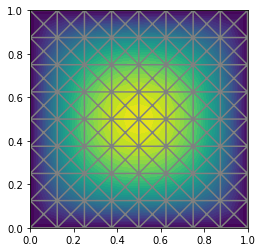

In [5]:
f = Constant(1)

n = 8
deg = 1
u, mesh = solve_laplacian_DirichletBC(n, n, f, deg)
plot(u)
plot(mesh)
plt.show()

## Andamento Convergenza

---




Considerando il problema:
\begin{equation}
-\nabla^2u=2\pi^2\sin(\pi x)\cos(\pi y)\space \space \space in \space \Omega
\end{equation}

\begin{equation}
u=0\space \space \space in\space\Gamma_D 
\end{equation}

La soluzione esatta è:
\begin{equation}
u=\sin(\pi x)\cos(\pi y)
\end{equation}

In [0]:
n = np.array([10, 10*2**1, 10*2**2, 10*2**3, 10*2**4, 10*2**5])
h = 1/n

eL2=[]
eH1=[]

for deg in [1,2]:
  f = Expression('2*pi*pi * sin(pi*x[0]) * sin(pi*x[1])', degree=deg+1)
  ue = Expression('sin(pi*x[0]) * sin(pi*x[1])', degree=deg+2)
  for i in n:
    u, mesh=solve_laplacian_DirichletBC(i, i, f, deg)
    eL2.append(errornorm(ue, u, 'L2'))
    eH1.append(errornorm(ue, u, 'H10'))



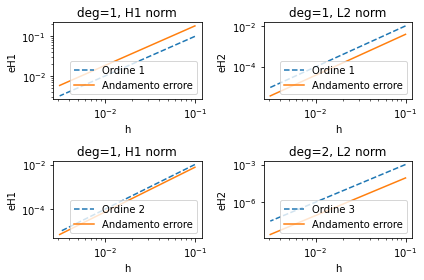

In [7]:
plt.subplot(2, 2, 1)
plt.loglog(h, h, '--', label='Ordine 1')
plt.loglog(h, eH1[:6], label='Andamento errore')
plt.legend(loc='lower right')
plt.xlabel('h')
plt.ylabel('eH1')
plt.title('deg=1, H1 norm')

plt.subplot(2, 2, 2)
plt.loglog(h, h**2, '--', label='Ordine 1')
plt.loglog(h, eL2[:6], label='Andamento errore')
plt.legend(loc='lower right')
plt.xlabel('h')
plt.ylabel('eH2')
plt.title('deg=1, L2 norm')


plt.subplot(2, 2, 3)
plt.loglog(h, h**2, '--', label='Ordine 2')
plt.loglog(h, eH1[6:], label='Andamento errore')
plt.legend(loc='lower right')
plt.xlabel('h')
plt.ylabel('eH1')
plt.title('deg=1, H1 norm')

plt.subplot(2, 2, 4)
plt.loglog(h, h**3, '--', label='Ordine 3')
plt.loglog(h, eL2[6:], label='Andamento errore')
plt.legend(loc='lower right')
plt.xlabel('h')
plt.ylabel('eH2')
plt.title('deg=2, L2 norm')
plt.tight_layout()
plt.show()

## Mixed BC


---



We consider the Laplace problem with mixed boundary conditions. On the unit square domain $\Omega = {[0,1]}^2$, the differential problem reads:
\begin{equation*}
  \begin{cases}
    -\nabla\cdot{( k \boldsymbol{\nabla}u)} = f, \qquad & \text{in }\Omega, \\
    u = g_D, \qquad & \text{on }\Gamma_D
      = \{(x,y) \in \mathbb{R}^2 \,|\, x \in \{0, 1\} \text{ and } y \in (0, 1) \}, \\
    -k \boldsymbol{\nabla} u\cdot{\boldsymbol{n}} = g_N, \qquad & \text{on }\Gamma_N
      = \{(x,y) \in \mathbb{R}^2 \,|\, x \in (0, 1) \text{ and } y = 0 \}, \\
    -k \boldsymbol{\nabla} u\cdot{\boldsymbol{n}} = \alpha (u - u_R), \qquad & \text{on }\Gamma_R
      = \{(x,y) \in \mathbb{R}^2 \,|\, x \in (0, 1) \text{ and } y = 1 \},
  \end{cases}
\end{equation*}
with problem data given by
\begin{equation*}
  k = 1, \quad
  \alpha = 1, \quad
  f = 0, \quad
  g_D = 0, \quad
  g_N = -1, \quad
  u_R = 1.
\end{equation*}

In [0]:
k = 1
alpha = 1
f = Constant(0)
uR = Constant(1)
gN = Constant(-1)

### Mesh Generation

In [0]:
n= 80
mesh = UnitSquareMesh(n, n, 'crossed')

dim = mesh.geometric_dimension()

### Space

In [0]:
deg = 1
V = FunctionSpace(mesh, 'CG', deg)

v = TestFunction(V)
u = TrialFunction(V)

### BC

In [0]:
boundary_markers  = MeshFunction('size_t', mesh, dim-1, 0)

class BottomBoundary(SubDomain):
  def inside(self, x, on_boundary):
    return on_boundary and near(x[1], 0)

class TopBoundary(SubDomain):
  def inside (self, x, on_boundary):
    return on_boundary and near(x[1], 1.0)

class LeftBoundary(SubDomain):
  def inside(self, x, on_boundary):
    return on_boundary and near(x[0], 0.0)

class RightBoundary(SubDomain):
  def inside(self, x, on_boundary):
    return on_boundary and near(x[0], 1.0)

bottom=BottomBoundary()
bottom.mark(boundary_markers, 1)

top=TopBoundary()
top.mark(boundary_markers, 2)

left=LeftBoundary()
left.mark(boundary_markers, 3)

right=RightBoundary()
right.mark(boundary_markers, 4)

Le condizioni al contorno di Dirichlet sono imposte fortemente (modificando lo spazio in cui si cerca la soluzione):

In [0]:
bc = [
    DirichletBC(V, Constant(0.0), boundary_markers, 3),      
    DirichletBC(V, Constant(0.0), boundary_markers, 4) ]

### Linear System

In [0]:
dx = Measure('dx', mesh)
ds = Measure('ds', domain=mesh, subdomain_data=boundary_markers)

a = k*dot(grad(u), grad(v))*dx + alpha*u*v*ds(2)
L = f*v*dx - gN*v*ds(1) + alpha*uR*v*ds(2)

A, b = assemble_system(a, L, bc)

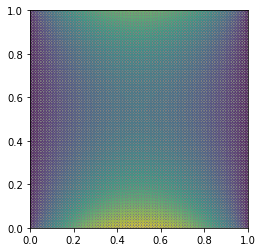

<Figure size 432x288 with 0 Axes>

In [19]:
u = Function(V)
u.rename('temperature', 'temperature')

x = u.vector()

precon = 'none'
#precon = 'amg'
solver = KrylovSolver('cg', precon)
solver.parameters["relative_tolerance"] = 5e-8
#solver.parameters["maximum_iterations"] = 1000
#solver.parameters['monitor_convergence'] = True

solver.solve(A, x, b)
figure = plot(u)
figure = plot(mesh, '--', linewidth=0.3)
plt.show(figure)